# Las losowy

Bagging tworzy skorelowane modele. To znaczy, że modele są bardzo zbliżone. Wracając do porónania do panelu ekspertów - jeśli dwóch ekspertów zawsze się zgadza, to jeden jest zbędny. W panelu ekspertów cenne są różne punkty widzenia. Podobnie jest dla modeli - chcemy by były ze sobą nieskorelowane. Uśrednianie skorelowanych modeli nie obniża wariancji modelu zespołowego i nie zwiększa jego dopasowania. 

Rozwiązaniem tego problemu jest las losowy. Nieskorelowane drzewa otrzymujemy przez użycie podzbioru kolumn do tworzenia drzew. Procedura tworzenia lasu losowego jest następująca
*	wybieramy wierwsze jak w metodzie Bagging
*	losujemy podzbiór kolumn


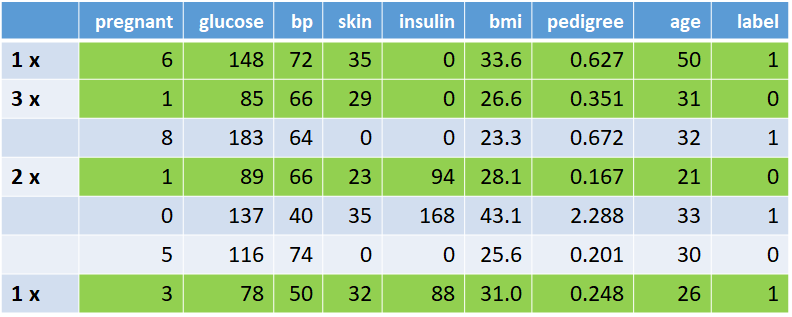

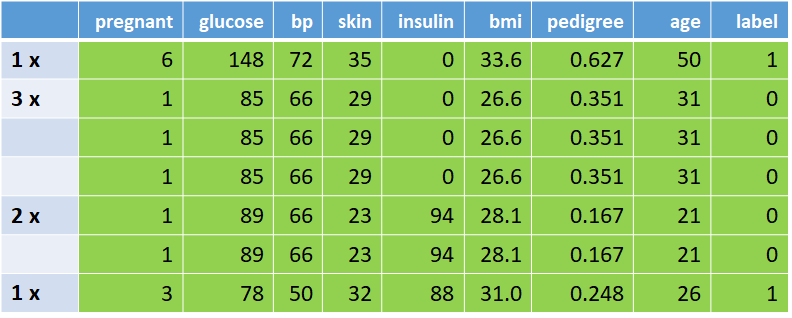

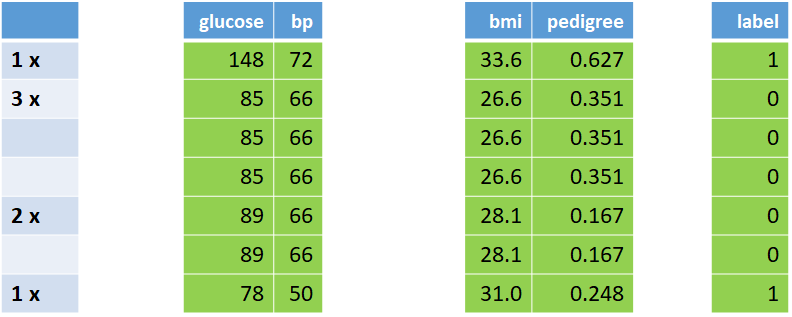

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import time

In [4]:
df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
df.shape

(768, 9)

In [6]:
X = df.drop(columns='Outcome')
y = df['Outcome']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [7]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators = 1000, n_jobs=-1, random_state=42)
rf.fit(X_train,y_train)

RandomForestClassifier(n_estimators=1000, n_jobs=-1, random_state=42)

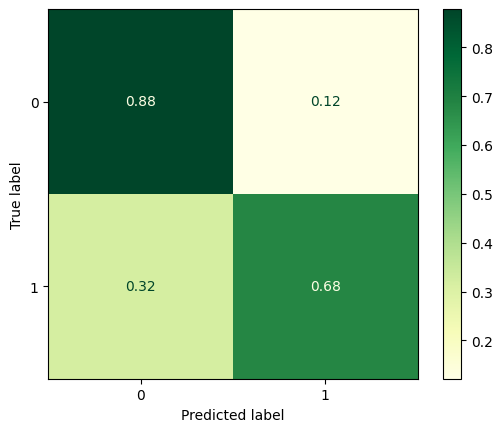

In [8]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
# parametr normalize jest ze zbioru {'true', 'pred', 'all', None} domyślnie = None
ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test, cmap='YlGn', normalize = 'true')
plt.show()

In [9]:
from sklearn.metrics import accuracy_score, recall_score
print('Accuracy:',accuracy_score(y_test,rf.predict(X_test)))
print('Recall:',recall_score(y_test,rf.predict(X_test)))

Accuracy: 0.8181818181818182
Recall: 0.6808510638297872


## Hiperparametry (w nawiasie nazwy w sklearn)

1. **mtry** (**max_features**) - liczba losowanych kolumn - typowa wartość, to $\sqrt{\text{liczba kolumn}}$ (domyślna wartość dla max_feature w sklearn)
2. **sample size** (**max_samples**) - liczba wierszy, które są losowane dla każdego z drzew - typowa wartość to n_samples, czyli liczba wszystkich wierszy (wartość domyślna dla max_samples)
3. **replacement** (**bootstrap**) - losowanie ze zwracaniem czy bez - zwykle wartość TRUE (wartość domyślna dla bootstrap)
4. **node size** (**min_samples_leaf**) - minimalna liczba obserwacji na liściu - zwykle 1 (domyślnie min_samples_leaf=1)
5. **number of trees** (**n_estimators**) - liczba drzew w lesie - zwykle to 500 (domyślnie **n_estimators**=100)
6. **splitting rule** - kryterium tworzenia drzewa - gini impurity (domyślnie **criterion = gini**) lub random (Extremely Randomize Trees - from sklearn.ensemble import ExtraTreesClassifier)

inne hiperparametery w sklearn:

7. **max_depth** (default=None) - maksymalna głębokość drzewa. Jeśli max_depth=None, to drzewa są budowane do momentu aż na każdym drzewie są: liście zawierają wiersze jednej kategorii (klasyfikacja) lub liście zawierają mniej niż  min_samples_split elementów.
8. **min_samples_split** (default=2) -  minamalna liczba elementów pozwalająca na dalszy podział w drzewie. Powinno spełniać warunek: 
$$\textbf{min_samples_split} \geq 2\times \textbf{min_samples_leaf}$$
9. **oob_score** (default=False) Czy wyliczać out-of-bag score. Można ustawić oob_score=True tylko, jeśli bootstrap=True.

### Liczba drzew

Liczba drzew w lesie jest parametrem, którego nie można przestrajać w klasycznym tego słowa znaczeniu, ale należy go ustawić na odpowiednio wysokim poziomie; im więcej drzew, tym lepiej.

Po pierwsze, za pomocą OOB_score znajdziemy optymalną liczbę drzew.

*Once the OOB error stabilizes, the training can be
terminated.* T. Hastie, R. Tibshirani and J. Friedman, “Elements of Statistical Learning Ed. 2”

C:\Users\HP\anaconda3\envs\wad\lib\site-packages\sklearn\ensemble\_forest.py:615: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


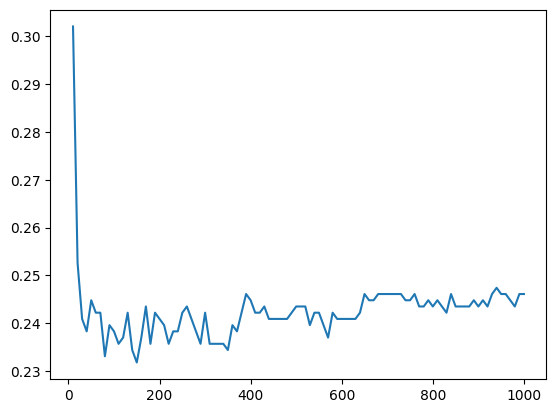

In [22]:
error_rate = []
min_estimators = 10
max_estimators = 1000


rf = RandomForestClassifier(warm_start=True, oob_score=True,
                               max_features="sqrt", n_jobs=-1)

for i in range(min_estimators,max_estimators+1, 10):
    rf.set_params(n_estimators=i)
    rf.fit(X,y)

    oob_error = 1 - rf.oob_score_
    error_rate.append(oob_error)

x_axis = range(min_estimators,max_estimators+1, 10)

plt.plot(x_axis, error_rate)
plt.show()


Wykres wygląda inaczej przy każdym uruchomieniu kodu. Jednak błąd stabilizuje się na poziomie 200 drzew.

**Uwaga** Szybkość zbieżności lasu losowego zależy nie tylko od rozważanego zbioru danych, ale także od hiperparametrów. 

### **mtry** (**max_features**)

Niższe wartości **mtry** prowadzą do bardziej zróżnicowanych i mniej skolrelowanych drzew, co zwiększa stabilność modelu zespołowego. Lasy zbudowane z niskim mtry mają również tendencję do lepszego wykorzystywania zmiennych o umiarkowanym wpływie na zmienną zależną - jeśli  w modelu są zmienne o silnym wpływie, to pozostałe rzadko stają się warunkami do podziału w drzewach.

Jednak niższe wartości mtry prowadzą również do tego, że drzewa osiągają przeciętnie gorsze wyniki – wybiera się prawdopodobnie zmienne nieistotne. 

**mtry** $= \sqrt{\text{liczba zmiennych}}$ (dla klasyfikacji) to zalecana wartość, która może być zmieniona dzięki wiedzy eksperckiej.

Jeśli istnieje wiele zmiennych predykcyjnych wpływających na wynik, to mtry powinno być małe.

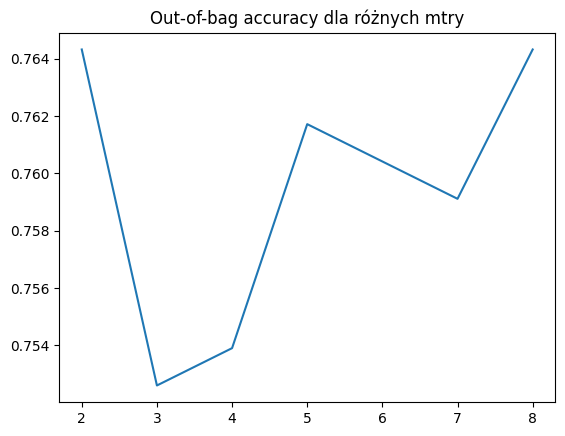

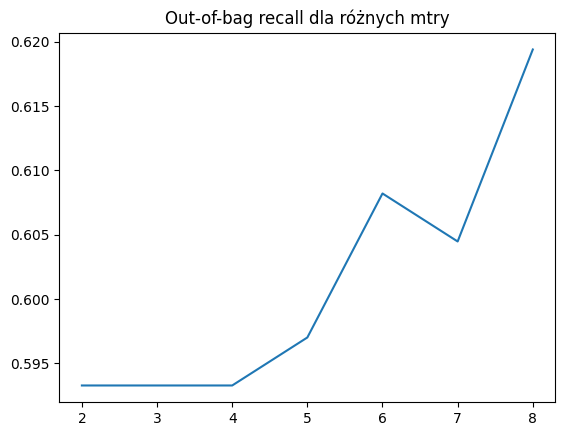

In [11]:
# dla mtry = 8 Random Forest staje się modelem Bagging 
mtry = [2,3,4,5,6,7,8] 
oob_accuracy = []
oob_recall = []
rf = RandomForestClassifier(n_estimators = 200, oob_score=True,
                               max_features="sqrt", n_jobs=-1)

for i in mtry:
    rf.set_params(max_features=i)
    rf.fit(X,y)
    y_oob = np.argmax(rf.oob_decision_function_,axis=1)
    oob_accuracy.append(accuracy_score(y,y_oob))
    oob_recall.append(recall_score(y,y_oob))

x_axis = range(2,9)

plt.plot(x_axis, oob_accuracy)
plt.title('Out-of-bag accuracy dla różnych mtry')
plt.show()
plt.plot(x_axis, oob_recall) 
plt.title('Out-of-bag recall dla różnych mtry')
plt.show()

### Liczba wierszy w drzewach docelowych (sample size)

Jeśli wiersze są losowane ze zwracaniem (**bootstrap=True**), to przeciętnie od 62% do 64.5% wierszy jest użytych w drzewie. To ma miejsce, gdy próba bootstrapingowa ma ten sam rozmiar co oryginalny zbiór (**max_samples=None**).  

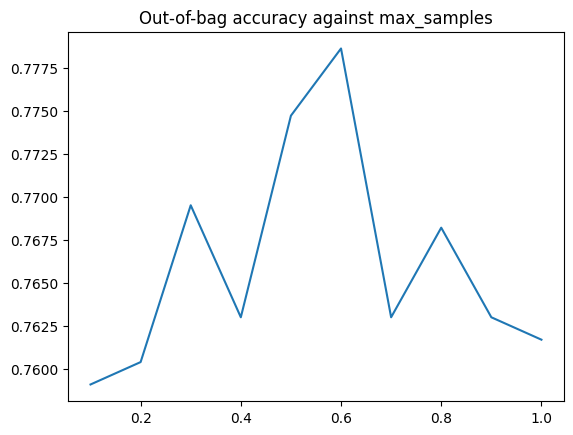

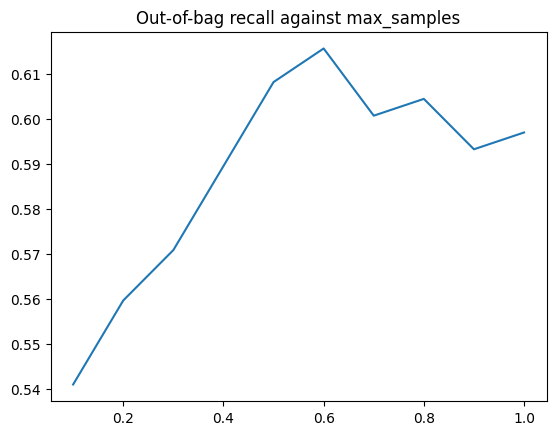

In [12]:
max_samples = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,None] 
oob_accuracy = []
oob_recall = []
rf = RandomForestClassifier(n_estimators = 200, oob_score=True,
                               max_features="sqrt", n_jobs=-1)

for i in max_samples:
    rf.set_params(max_samples=i)
    rf.fit(X,y)
    y_oob = np.argmax(rf.oob_decision_function_,axis=1)
    oob_accuracy.append(accuracy_score(y,y_oob))
    oob_recall.append(recall_score(y,y_oob))

x_axis = np.linspace(0.1,1.0,10)

plt.plot(x_axis, oob_accuracy)
plt.title('Out-of-bag accuracy against max_samples')
plt.show()
plt.plot(x_axis, oob_recall) 
plt.title('Out-of-bag recall against max_samples')
plt.show()

### Random splitting rule - Extremely Randomize Trees

W ekstremalnie losowych drzewach losowość idzie o krok dalej w sposobie obliczania podziałów. Podobnie jak w losowych lasach, losuje się kolumny, ale zamiast szukać najlepszych progów do podziału drzewa, są one losowane dla każdego wiersza, a najlepszy z nich jest wybierany jako reguła podziału. Zwykle pozwala to **nieco zredukować wariancję modelu**, kosztem **nieco większego błędu**:

In [13]:
from sklearn.ensemble import ExtraTreesClassifier

rf = RandomForestClassifier(n_estimators = 200, oob_score=True,
                               max_features="sqrt", n_jobs=-1)
et = ExtraTreesClassifier(n_estimators = 200, oob_score=True, bootstrap=True,
                               max_features="sqrt", n_jobs=-1)

start_time = time.time()
rf.fit(X,y)
print('Random Forest')
print('time:', round(time.time() - start_time, 2))
y_oob = np.argmax(rf.oob_decision_function_,axis=1)
print('OOB accuracy:',accuracy_score(y,y_oob))
print('OOB recall:',recall_score(y,y_oob))


start_time = time.time()
et.fit(X,y)
print('Extremely Randomize Trees')
print('time:', round(time.time() - start_time, 2))
y_oob = np.argmax(et.oob_decision_function_,axis=1)
print('OOB accuracy:',accuracy_score(y,y_oob))
print('OOB recall:',recall_score(y,y_oob))



Random Forest
time: 0.55
OOB accuracy: 0.7669270833333334
OOB recall: 0.5932835820895522
Extremely Randomize Trees
time: 0.54
OOB accuracy: 0.7578125
OOB recall: 0.5559701492537313


### Node size (**min_samples_leaf**) i inne parametry przycinania drzew 

Parametr **min_sample_leaf** określa minimalną liczbę obserwacji na liściu. Zmniejszenie go prowadzi do drzew o większej głębokości. Domyślnie jest ustawiony na 1. Istnieją eksperymentalne dowody na to, że czas obliczeń **spada** wykładniczo wraz ze wzrostem rozmiaru liści. W przypadku dużych zbiorów danych pomocne może być ustawienie tego parametru na wartość wyższą niż domyślna, ponieważ znacznie skraca to czas wykonywania, często bez znacznej utraty jakości predykcji.

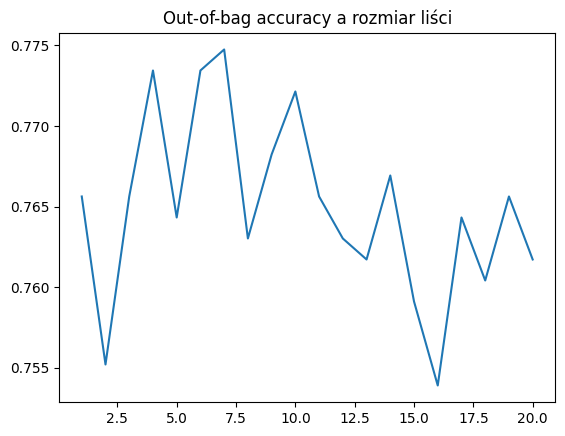

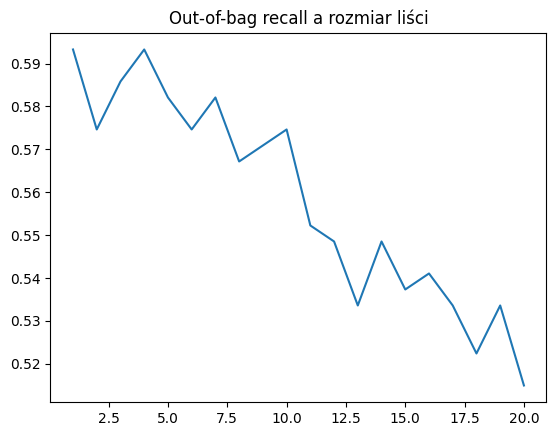

In [14]:

msl = range(1,21) 
oob_accuracy = []
oob_recall = []
rf = RandomForestClassifier(n_estimators = 200, oob_score=True,
                               max_features="sqrt", n_jobs=-1)

for i in msl:
    rf.set_params(min_samples_leaf=i)
    rf.fit(X,y)
    y_oob = np.argmax(rf.oob_decision_function_,axis=1)
    oob_accuracy.append(accuracy_score(y,y_oob))
    oob_recall.append(recall_score(y,y_oob))

x_axis = range(1,21)

plt.plot(x_axis, oob_accuracy)
plt.title('Out-of-bag accuracy a rozmiar liści')
plt.show()
plt.plot(x_axis, oob_recall) 
plt.title('Out-of-bag recall a rozmiar liści')
plt.show()


Parametry **min_sample_leaf**,  **max_depth** oraz **min_samples_split** są też używane do przycinania drzew w lesie. 

## Grid Search CV czy Randomize Search CV?

Zabaczmy, jak szybko RandomForestClassifier jest uczony.

In [15]:
rf = RandomForestClassifier(n_estimators = 200, oob_score=True,
                               max_features="sqrt", n_jobs=-1)
start_time = time.time()
rf.fit(X,y)
print("%s seconds" % (round(time.time() - start_time, 2)))

0.53 seconds


Załóżmy, że chcemy wybrać parametry modelu RandomForestClassifier spośród następujących

param_grid = {'criterion':['gini', 'entropy'], 'max_depth': np.arange(1, 26), 
              'min_samples_split': np.arange(2, 26), 'max_features':np.arange(2,8), 
              'class_weight':['balanced', 'balanced_subsample', 'None'] }

Parametrów jest $2\times 25\times 24\times 6\times 2=14400$. 5-fold CV produkuje 5 modeli. Każdy jest trenowany przez 1 sekundę. Procedura GridSearchCV zajmie zatem 

$14400\times 5 = 72000$ sekund. To 20 godzin. 

Jeśli nie mamy lepszego komputera (ani czasu), to musimy ograniczyć liczbę parametrów lub użyć RandomizedSearchCV z n_iter=100. To zabierze około 100 sekund, czyli niecałe 2 minuty. 

In [16]:
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestClassifier(n_estimators = 600, n_jobs=-1)

param_grid = {'max_depth': [2,3,4,5,6,7,8,None], 
              'min_samples_leaf': range(1,31), 'max_features':[2,3,4,5,6,7,8], 
              'max_samples': [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,None] 
              }
rf_rscv = RandomizedSearchCV(rf, param_grid,n_iter=100, cv=5, scoring='recall', n_jobs=-1)
rf_rscv.fit(X, y)

RandomizedSearchCV(cv=5,
                   estimator=RandomForestClassifier(n_estimators=600,
                                                    n_jobs=-1),
                   n_iter=100, n_jobs=-1,
                   param_distributions={'max_depth': [2, 3, 4, 5, 6, 7, 8,
                                                      None],
                                        'max_features': [2, 3, 4, 5, 6, 7, 8],
                                        'max_samples': [0.1, 0.2, 0.3, 0.4, 0.5,
                                                        0.6, 0.7, 0.8, 0.9,
                                                        None],
                                        'min_samples_leaf': range(1, 31)},
                   scoring='recall')

In [17]:
rf_rscv.best_params_

{'min_samples_leaf': 7,
 'max_samples': 0.9,
 'max_features': 7,
 'max_depth': None}

In [18]:
rf_rscv.best_score_

0.5972746331236898

## Znacznie zmiennych

Losowy las może być używany do dwóch różnych celów:
1. Budowania modelu
2. Oceny, które zmienne są najważniejsze.

Dodajmy jedną losową cechę. Powinna być ona zupełnie nieistotna dla wyjaśnienia zmiennej zależnej.

In [19]:
X['random'] = np.random.random(size = len(X))
y = df['Outcome']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

### Gini variable importance 

Let us compute the Gini variable importance measure. It is calculated as the mean of Gini variable importance of decision trees from RF.  



Czas potrzebny do wyliczeń: 1.334 seconds


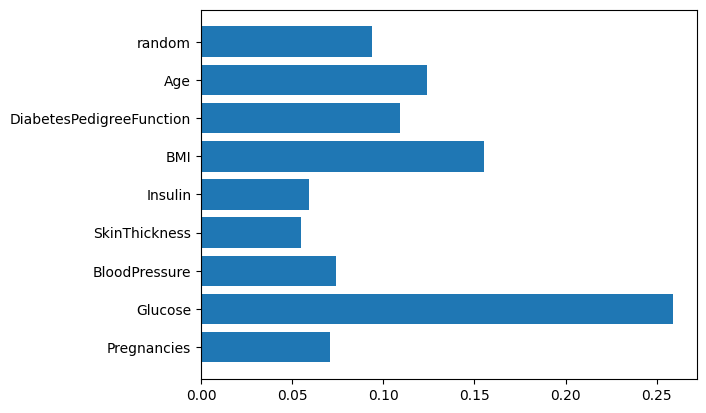

In [20]:
rf = RandomForestClassifier(n_estimators = 6000, n_jobs=-1)
rf.fit(X,y)
start_time = time.time()
feature_importances = rf.feature_importances_
elapsed_time = time.time() - start_time
print(f"Czas potrzebny do wyliczeń: "
      f"{elapsed_time:.3f} seconds")
plt.barh(X.columns, feature_importances)
plt.show()

Gini variable importance przypisuje wyższe wartości zmiennym z większą liczbą kategorii lub zmiennym ciągłym oraz zmiennym kategorycznym z kategoriami o jednakowej wielkości, nawet jeśli wszystkie zmienne są niezależne od zmiennej zależnej.

### Permutation variable importance measure

Inna miara **permutation variable importance measure**.   

permutation variable importance measure jest znacznie bardziej kosztowna obliczeniowo

Czas potrzebny do obliczeń: 127.807 seconds


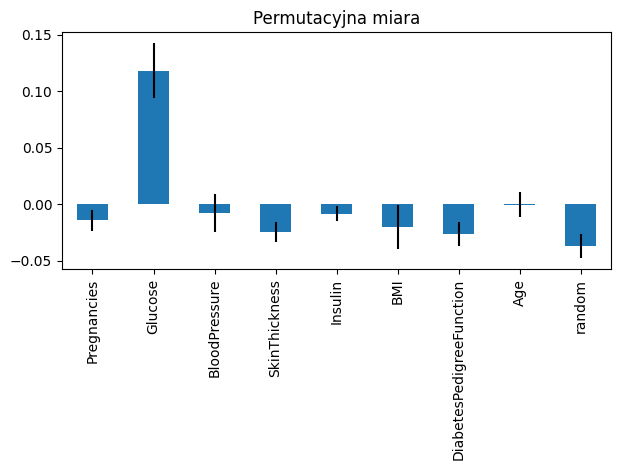

In [21]:
from sklearn.inspection import permutation_importance

rf = RandomForestClassifier(n_estimators = 6000, n_jobs=-1)
rf.fit(X_train,y_train)

start_time = time.time()
result = permutation_importance(
    rf, X_test, y_test, n_repeats=10)
elapsed_time = time.time() - start_time
print(f"Czas potrzebny do obliczeń: "
      f"{elapsed_time:.3f} seconds")

forest_importances = pd.Series(result.importances_mean, index=X.columns)

fig, ax = plt.subplots()
forest_importances.plot.bar(yerr=result.importances_std, ax=ax)
ax.set_title("Permutacyjna miara")
fig.tight_layout()
plt.show()